In [1]:
from __future__ import annotations

import gzip
import json
from pathlib import Path
from typing import Any
import pickle
import ipywidgets as widgets
from ipywidgets import interact



import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
   accuracy_score,
   average_precision_score,
   classification_report,
   confusion_matrix,
   f1_score,
   precision_recall_curve,
   precision_score,
   recall_score,
   roc_auc_score,
   roc_curve,
)
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingClassifier

from data import wrangle


---
### Eploratory Data Analysis

In [2]:
# Listing the data
data_dir = Path("C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data")
paths = sorted(data_dir.glob("*.json*"))
paths

[WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009-mvp-features.json.gz'),
 WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009.json.gz'),
 WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/taiwan-bankruptcy-data-test-features.json.gz'),
 WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/taiwan-bankruptcy-data.json.gz')]

In [3]:
# Grouping the dataset
poland_paths = sorted([p for p in paths if "poland" in p.name.lower()])
taiwan_paths = sorted([p for p in paths if "taiwan" in p.name.lower()])

poland_paths, taiwan_paths

([WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009-mvp-features.json.gz'),
  WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009.json.gz')],
 [WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/taiwan-bankruptcy-data-test-features.json.gz'),
  WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/taiwan-bankruptcy-data.json.gz')])

In [4]:
# Loading the json file safely
def load_json(path: str | Path) -> Any:
    """Load a JSON file that may be gzip-compressed.

    Parameters
    ----------
    path
        Path to a ``.json`` or ``.json.gz`` file.

    Returns
    -------
    Any
        Parsed JSON (often a dict, sometimes a list).
    """
    p = Path(path) # use Path

    if p.suffix == ".gz":
        with gzip.open(p, "rt", encoding ="utf-8") as f:
            return json.load(f)

    with p.open("rt", encoding="utf-8") as f:
        return json.load(f)

In [5]:
def extract_records(payload: Any) -> list[dict[str, Any]]:
    """
    Extract the list of record dictionaries from the dataset payload.

    Parameters
    ----------
    payload
        Parsed JSON payload (expected: dict with records under a known key).

    Returns
    -------
    list of dict
        The dataset records.

    Raises
    ------
    KeyError
        If neither ``data`` nor ``observations`` is present.
    TypeError
        If the record container exists but is not a list of dicts.
    """
    if not isinstance(payload, dict):
        raise TypeError("Expected the JSON payload to be a dict.")

    if "data" in payload:
        records = payload["data"]
    elif "observations" in payload:
        records = payload["observations"]
    else:
        raise KeyError(
            "Could not find records. Expected key 'data' or 'observations'. "
            f"Found keys: {list(payload.keys())}"
        )

    if not isinstance(records, list):
        raise TypeError("Expected the records container to be a list.")

    if records and not isinstance(records[0], dict):
        raise TypeError("Expected records to be a list of dicts.")

    return records

In [6]:
# Converting the records to  dataframe
def records_to_frame(records: list[dict[str, Any]]) -> pd.DataFrame:
    """
    Convert a list of record dicts into a DataFrame.

    Parameters
    ----------
    records
        List of dictionaries, one per observation.

    Returns
    -------
    pandas.DataFrame
        DataFrame created from records.
    """
    has_nested = any(
        isinstance(v, (dict, list))
        for r in records
        for v in r.values()
    )
    if has_nested:
        return pd.DataFrame.from_records(records)
    return pd.DataFrame.from_records(records)

In [7]:
# Standardisation
def normalize_columns(columns: list[str]) -> list[str]:
    """
    Normalize column names to a consistent snake_case style.

    Parameters
    ----------
    columns
        Original column names.

    Returns
    -------
    list of str
        Normalized column names.
    """
    out: list[str] = []
    for c in columns:
        c = str(c)
        c = c.strip()  # strip
        c = c.lower() # lower
        c = c.replace(" ", "_") # replace space by underscore
        c = c.replace("-", "_") # replace dash by underscore
        # check if ch is alpha numeric
        c = "".join(ch for ch in c if ch.isalnum() or ch == "_")
        while "__" in c:
            c = c.replace("__", "_")  # replace double underscore by single underscore
        out.append(c)
    return out

In [8]:
# Cleaning the dataset
def clean_financials(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean dataset for modeling (simple version).

    Parameters
    ----------
    df
        Raw DataFrame extracted from JSON.

    Returns
    -------
    pandas.DataFrame
        Cleaned DataFrame with normalized columns and numeric values where
        possible.
    """
    df2 = df.copy()
    df2.columns = normalize_columns([str(c) for c in df2.columns])

    for col in df2.columns:
        df2[col] = pd.to_numeric(df2[col], errors="coerce")

    return df2

In [9]:
# Wrap all these functions into a single callable function
def wrangle(path: str | Path) -> pd.DataFrame:
    """
    Load + transform a bankruptcy dataset into a clean DataFrame.

    Parameters
    ----------
    path
        Path to a ``.json`` or ``.json.gz`` file.

    Returns
    -------
    pandas.DataFrame
        Cleaned DataFrame ready for analysis.
    """
    payload = load_json(path)
    records = extract_records(payload)
    df_raw = records_to_frame(records)
    return clean_financials(df_raw)

In [10]:
# Load all datasets
datasets_path: dict[str, Path] = {
    "poland_features": next(
        p for p in poland_paths if "features" in p.name.lower()
    ),
    "poland_full": next(
        p for p in poland_paths if "features" not in p.name.lower()
    ),
    "taiwan_features": next(
        p for p in taiwan_paths if "features" in p.name.lower()
    ),
    "taiwan_full": next(
        p for p in taiwan_paths if "features" not in p.name.lower()
    ),
}

datasets_path

{'poland_features': WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009-mvp-features.json.gz'),
 'poland_full': WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009.json.gz'),
 'taiwan_features': WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/taiwan-bankruptcy-data-test-features.json.gz'),
 'taiwan_full': WindowsPath('C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/taiwan-bankruptcy-data.json.gz')}

In [11]:
frames: dict[str, pd.DataFrame] = {
    name: wrangle(path) for name, path in datasets_path.items()
}

{k: v.shape for k, v in frames.items()}

{'poland_features': (526, 65),
 'poland_full': (9977, 66),
 'taiwan_features': (682, 96),
 'taiwan_full': (6137, 97)}

In [12]:
# Data validation
def expected_feature_set(n_feats: int) -> set[str]:
    """Return expected feature columns: feat_1..feat_n."""
    return {f"feat_{i}" for i in range(1, n_feats + 1)}

poland_feats = expected_feature_set(64)
taiwan_feats = expected_feature_set(95)

checks = [
    ("poland_features", "company_id", poland_feats, False),
    ("poland_full", "company_id", poland_feats, True),
    ("taiwan_features", "id", taiwan_feats, False),
    ("taiwan_full", "id", taiwan_feats, True),
]

for name, id_col, feat_set, has_target in checks:
    df_ = frames[name]
    cols = set(df_.columns)

    assert id_col in cols, f"{name}: missing id column {id_col!r}"

    missing_feats = feat_set - cols
    assert not missing_feats, (
        f"{name}: missing features (sample): "
        f"{sorted(missing_feats)[:10]}"
    )

    if has_target:
        assert "bankrupt" in cols, f"{name}: expected 'bankrupt'"
    else:
        assert "bankrupt" not in cols, f"{name}: did not expect 'bankrupt'"

print("All column checks passed!")

All column checks passed!


In [13]:
# Check for imbalance ratio
def imbalance_ratio(y: pd.Series) -> float:
    """Compute imbalance ratio: majority_count / minority_count."""
    s = y.dropna().astype(int)  # drop Nan from `y` and cast values to int
    counts = s.value_counts()  # counts of unique values from `s`

    if counts.shape[0] < 2:
        # If the size of `counts` is less than 2, the result is invalid,
        # as it should contain counts for both values (0 and 1).
        return float("nan")

    majority = counts.max()  # get the max from the `counts`
    minority = counts.min()  # get the min from the `counts`

    if minority == 0.0:
        # division by zero is invalid, so returns "inf"
        return float("inf")

    return float(majority /minority) # calculate the division between majority and minority

In [14]:
labeled = {
    "poland_full": frames['poland_full'],  # get the "poland_full" from `frames`
    "taiwan_full": frames['taiwan_full'], # get the "taiwan_full" from `frames`
}

for name, df_ in labeled.items():
    vals = set(df_["bankrupt"].dropna().astype(int).unique())
    assert vals.issubset({0, 1}), f"{name} target not binary: {sorted(vals)}"

    ir = imbalance_ratio(df_["bankrupt"]) # get the imbalance ratio for "bankrupt" from `df_`
    print(f"{name}: imbalance ratio = {ir:.2f}")

poland_full: imbalance ratio = 20.36
taiwan_full: imbalance ratio = 31.30


---
### Logistic Regression

In [15]:
# Load the poland dataset
poland_path = Path("C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009.json.gz")
poland_df = wrangle(poland_path)

poland_df.shape

(9977, 66)

In [16]:
# Check the class imbalance
target_counts = poland_df["bankrupt"].value_counts()
target_counts

bankrupt
False    9510
True      467
Name: count, dtype: int64

In [17]:
target_rate = poland_df["bankrupt"].value_counts(normalize=True)
target_rate

bankrupt
False    0.953192
True     0.046808
Name: proportion, dtype: float64

Text(0, 0.5, 'count')

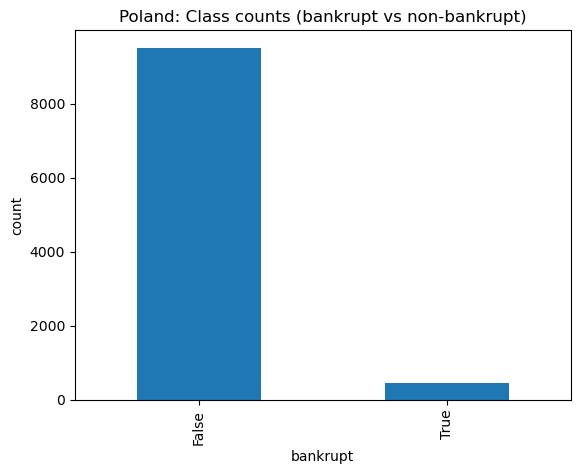

In [18]:
# Visualising the class imbalance
ax = target_counts.sort_index().plot(kind="bar")  # create `ax` for a bar chart from `target_counts`
ax.set_title("Poland: Class counts (bankrupt vs non-bankrupt)")  # change the ax title
ax.set_xlabel("bankrupt")  # change the ax x-axis label
ax.set_ylabel("count")  # change the ax y-axis label

In [19]:
# drop NaN observations and make a copy of poland_df
poland_df = poland_df.dropna().copy()

# select feature columns that starts with "feat_"
feature_cols = [col for col in poland_df.columns if col.startswith("feat_") ]

X = poland_df[feature_cols]
y = poland_df['bankrupt'].astype(int)  # also force the value as integer type.

X.shape, y.shape

((4658, 64), (4658,))

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.25, random_state=42)

X_train.shape, X_test.shape

((3493, 64), (1165, 64))

In [21]:
# Create a dummy baseline
dummy = DummyClassifier(strategy="most_frequent")  # use DummyClassifier with most frequent strategy
# train the dummy model on X_train and y_train
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

In [22]:
# Evaluate the dummy baseline
acc_dummy = accuracy_score(y_test, y_pred_dummy)
prec_dummy = precision_score(y_test, y_pred_dummy, zero_division=0)
rec_dummy = recall_score(y_test, y_pred_dummy, zero_division=0)
f1_dummy = f1_score(y_test, y_pred_dummy, zero_division=0)

acc_dummy, prec_dummy, rec_dummy, f1_dummy

(0.9759656652360515, 0.0, 0.0, 0.0)

In [23]:
# create a confusion matrix between y_test and y_pred_dummy
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_dummy

array([[1137,    0],
       [  28,    0]])

In [24]:
# instantiate the logistic regression model with `max_iter=1100` and `solver="lbfgs"`
log_reg = LogisticRegression(
    max_iter=1100,
    solver="lbfgs",
    class_weight='balanced'
)

log_reg.fit(X_train, y_train)  # train log_reg with X_train and y_train

C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1100
,multi_class,'deprecated'


In [25]:
# use log_reg to predict on X_test
y_pred_lr = log_reg.predict(X_test)
# use `log_reg` to predict probabilities on `X_test`
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

y_pred_lr[:5], y_proba_lr[:5]

(array([1, 1, 0, 0, 1]),
 array([0.71420024, 0.50407679, 0.49209996, 0.28284946, 0.55127749]))

In [26]:
# compute metrics between y_test and y_pred_lr
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

acc_lr, prec_lr, rec_lr, f1_lr

(0.7896995708154506,
 0.053497942386831275,
 0.4642857142857143,
 0.0959409594095941)

In [27]:
# compute the confusion matrix between `y_test` and `y_pred_lr`
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr

array([[907, 230],
       [ 15,  13]])

In [28]:
# calculate ROC-AUC using `y_test` and `y_proba_lr`
roc_auc = roc_auc_score(y_test, y_proba_lr)
# calculate the average precision score using `y_test` and `y_proba_lr`
pr_auc = average_precision_score(y_test, y_proba_lr)

roc_auc, pr_auc

(0.746042216358839, 0.05342663857135254)

In [29]:
# call the classification_report for y_test, y_pred_lr, digits=3 and zero_division=0
classification_report(
    y_test,
    y_pred_lr,
    digits=3,
    zero_division=0,
)

'              precision    recall  f1-score   support\n\n           0      0.984     0.798     0.881      1137\n           1      0.053     0.464     0.096        28\n\n    accuracy                          0.790      1165\n   macro avg      0.519     0.631     0.488      1165\nweighted avg      0.961     0.790     0.862      1165\n'

In [30]:
assert (y_pred_lr != y_pred_dummy).any()

In [31]:
def evaluate_binary_classifier(
    *,
    name: str,
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray,
    y_proba: np.ndarray,
) -> dict[str, float | str]:
    """
    Compute key metrics for binary classification.

    Parameters
    ----------
    name
        Label for the model (used in the results table).
    y_true
        True labels (0/1).
    y_pred
        Predicted labels (0/1).
    y_proba
        Predicted probabilities for class 1.

    Returns
    -------
    dict of str to float | str
        Metrics: accuracy, precision, recall, f1, roc_auc, pr_auc.
    """
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

In [32]:
# Plain logistic regression
log_reg_plain = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
)
log_reg_plain.fit(X_train, y_train)

y_pred_plain = log_reg_plain.predict(X_test)
y_proba_plain = log_reg_plain.predict_proba(X_test)[:, 1]

C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
# create a pipeline log_reg_scaled with 2 steps: MinMaxScaler as scaler and LogisticRegression as model (using the same parameters used in Code 5.2.9.2)
log_reg_scaled =Pipeline(
    steps=[ ("scaler", MinMaxScaler()),
             ("model", LogisticRegression(max_iter= 1000,
                                    solver= 'lbfgs',

                                   ))])
# train `log_reg_scaled` using `X_train` and `y_train`
log_reg_scaled.fit(X_train, y_train)

# generate predictions for `X_test` using `log_reg_scaled`
y_pred_scaled = log_reg_scaled.predict(X_test)
# predict probabilities for `X_test` using `log_reg_scaled`,
# and select the class 1 probabilities with `[:, 1]`
y_proba_scaled = log_reg_scaled.predict_proba(X_test)[:, 1]

In [34]:
rows = [
    evaluate_binary_classifier(
        name="LogReg (no scaling)",
        y_true=y_test,
        y_pred=y_pred_plain,
        y_proba=y_proba_plain,
    ),
    evaluate_binary_classifier(
        name="LogReg + MinMaxScaler",
        y_true=y_test,
        y_pred=y_pred_scaled,
        y_proba=y_proba_scaled,
    ),
]

results = pd.DataFrame(rows).set_index("model")
results

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
LogReg (no scaling),0.975966,0.0,0.0,0.0,0.483949,0.023761
LogReg + MinMaxScaler,0.975966,0.0,0.0,0.0,0.745948,0.071330


In [35]:
# generate the confusion matrix using y_test and y_pred_plain
cm_plain = confusion_matrix(y_test, y_pred_plain)
# generate the confusion matrix using y_test and y_pred_scaled
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

cm_plain, cm_scaled

(array([[1137,    0],
        [  28,    0]]),
 array([[1137,    0],
        [  28,    0]]))

Text(0, 0.5, 'True Positive Rate (TPR / Recall)')

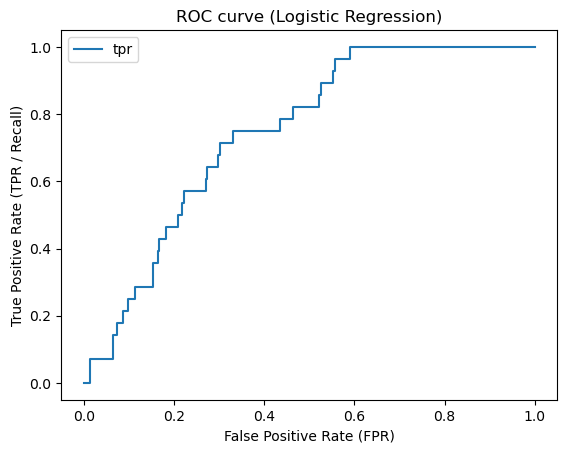

In [36]:
# compute the ROC curve from `y_test` and `y_proba_lr`
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_lr)

ax = pd.DataFrame({"fpr": fpr, "tpr": tpr}).plot(x="fpr", y="tpr")
ax.set_title("ROC curve (Logistic Regression)")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR / Recall)")

Text(0, 0.5, 'Precision')

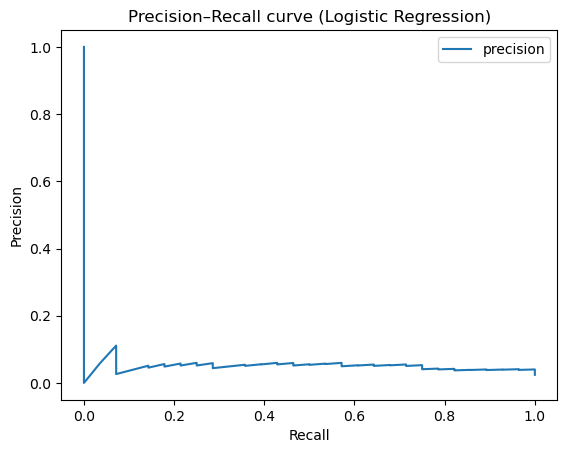

In [37]:
# compute the Precision–Recall curve from `y_test` and `y_proba_lr`
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(
    y_test, y_proba_lr
)

ax = pd.DataFrame({"recall": rec_curve, "precision": prec_curve}).plot(
    x="recall",
    y="precision",
)
ax.set_title("Precision–Recall curve (Logistic Regression)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

In [38]:
prevalence = float(y_test.mean())
prevalence

0.0240343347639485

In [39]:
threshold = 0.1
y_pred_thr = (y_proba_lr >= threshold).astype(int)

precision_thr = precision_score(y_test, y_pred_thr, zero_division=0)
recall_thr = recall_score(y_test, y_pred_thr, zero_division=0)
f1_thr = f1_score(y_test, y_pred_thr, zero_division=0)

precision_thr, recall_thr, f1_thr

(0.025112107623318385, 1.0, 0.048993875765529306)

---
### Random Forest Classification

In [40]:
poland_path = Path("C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009.json.gz")
poland_df = wrangle(poland_path)

poland_df.shape

(9977, 66)

In [41]:
feature_cols = [c for c in poland_df.columns if c.startswith("feat_")]

X = poland_df[feature_cols]
y = poland_df["bankrupt"].astype(int)

X.shape, y.shape

((9977, 64), (9977,))

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

((7482, 64), (2495, 64))

In [43]:
baseline_lr = make_pipeline(  
     SimpleImputer(strategy="median") ,
     LogisticRegression(max_iter = 1000,
                               solver= 'lbfgs',) 
)

# fit baseline_lr using `X_train` and `y_train`
baseline_lr.fit(X_train, y_train)

# predict the target from `X_test` using the `baseline_lr` model
y_pred_lr = baseline_lr.predict(X_test)
# gets the predicted probability of the positive class (1) from the baseline_lr model.
y_proba_lr = baseline_lr.predict_proba(X_test)[:, 1]

C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
baseline_metrics = {
    "precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "f1": f1_score(y_test, y_pred_lr, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_lr),
}
baseline_metrics

{'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5608713779445487}

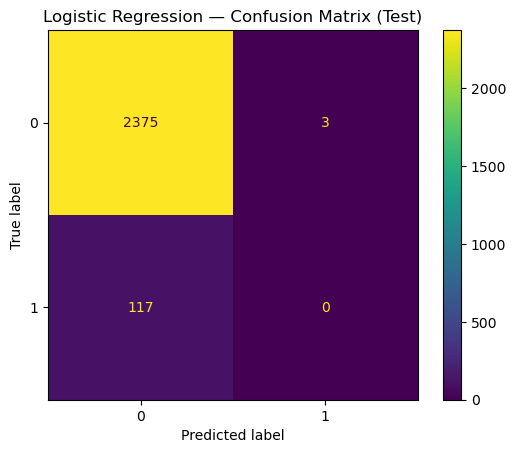

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    values_format="d",
)
plt.title("Logistic Regression — Confusion Matrix (Test)")
plt.show()

In [46]:
# build a preprocessing + model pipeline and train a random forest with balanced class weights for imbalanced data
rf_simple = make_pipeline(
    SimpleImputer(strategy= "median"),
    RandomForestClassifier(class_weight="balanced",
                          n_estimators=300,
                          random_state=42,
                          n_jobs= -1
                          )
)
# fit the pipeline on the training split
rf_simple.fit(X_train, y_train)

# predict class labels on the test split
y_pred_rf = rf_simple.predict(X_test)
# predict probabilities on the test split and select class 1 probabilities
y_proba_rf = rf_simple.predict_proba(X_test)[:, 1]

In [47]:
# compute core metrics on the test set using class predictions and use `zero_division=0` to avoid warnings when no positives are predicted
rf_metrics = {
    "precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_rf),
}

rf_metrics

{'precision': 0.6666666666666666,
 'recall': 0.06837606837606838,
 'f1': 0.12403100775193798,
 'roc_auc': 0.8412226032074644}

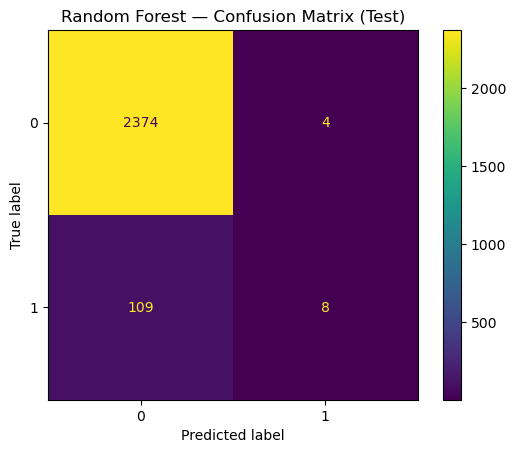

In [48]:
# plot the confusion matrix to see TP/FP/TN/FN counts at the default threshold
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    values_format="d",
)
# add a readable title and render the plot
plt.title("Random Forest — Confusion Matrix (Test)")
plt.show()

In [49]:
# build a compact comparison table with the baseline and random forest metrics
compare = pd.DataFrame(
    [
        {"model": "LogReg baseline", **baseline_metrics},
        {"model": "Random Forest", **rf_metrics},
    ]
).set_index("model")

compare

,precision,recall,f1,roc_auc
model,,,,
LogReg baseline,0.000000,0.000000,0.000000,0.560871
Random Forest,0.666667,0.068376,0.124031,0.841223


In [50]:
# compute the same metrics on train vs test to check for overfitting

y_pred_rf_train = rf_simple.predict(X_train)
y_proba_rf_train = rf_simple.predict_proba(X_train)[:, 1]

rf_train_metrics = {
    "precision": precision_score(y_train, y_pred_rf_train, zero_division=0),
    "recall": recall_score(y_train, y_pred_rf_train, zero_division=0),
    "f1": f1_score(y_train, y_pred_rf_train, zero_division=0),
    "roc_auc": roc_auc_score(y_train, y_proba_rf_train),
}

rf_train_metrics

{'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}

In [51]:
# compare train vs test side-by-side
rf_train_test = pd.DataFrame(
    [rf_train_metrics, rf_metrics],
    index=["train", "test"],
)

rf_train_test

,precision,recall,f1,roc_auc
train,1.000000,1.000000,1.000000,1.000000
test,0.666667,0.068376,0.124031,0.841223


In [52]:
# create the oversampler (fixed seed for reproducibility)
ros = RandomOverSampler(random_state=42)
# oversample the training split only (never oversample the test set)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# inspect the new training shape and class balance after resampling
X_train_over.shape, pd.Series(y_train_over).value_counts()

((14264, 64),
 bankrupt
 0    7132
 1    7132
 Name: count, dtype: int64)

In [53]:
 #build a pipeline:
rf_over = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ),
)
# train the pipeline on the oversampled training split
rf_over.fit(X_train_over, y_train_over)

# predict class labels on the original (unchanged) test split
y_pred_rf_over = rf_over.predict(X_test)
# predict probabilities on the test split and select class 1 probabilities
y_proba_rf_over = rf_over.predict_proba(X_test)[:, 1]

In [54]:
# compute core metrics on the unchanged test set
rf_over_metrics = {
    "precision": precision_score(y_test, y_pred_rf_over, zero_division=0),
    "recall": recall_score(y_test, y_pred_rf_over, zero_division=0),
    "f1": f1_score(y_test, y_pred_rf_over, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_rf_over),
}

rf_over_metrics

{'precision': 0.6666666666666666,
 'recall': 0.13675213675213677,
 'f1': 0.22695035460992907,
 'roc_auc': 0.8461915852580276}

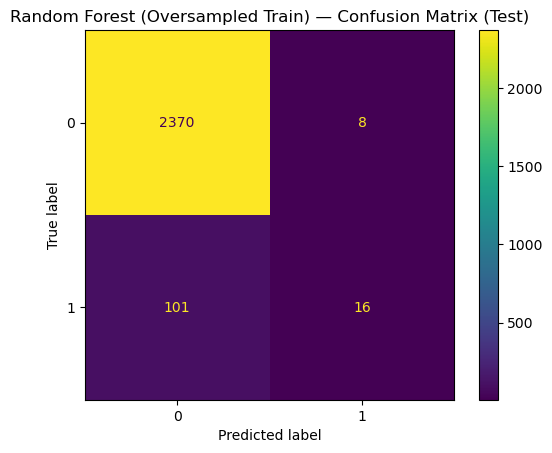

In [55]:
# visualize TP/FP/TN/FN counts for the oversampled-training model on the test set
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_over,
    values_format="d",
)
# add a readable title and render the plot
plt.title("Random Forest (Oversampled Train) — Confusion Matrix (Test)")
plt.show()

In [56]:
# build a comparison table across models using the same metric keys
compare2 = pd.DataFrame(
    [
        {"model": "LogReg baseline", **baseline_metrics},
        {"model": "RF (class_weight=balanced)", **rf_metrics},
        {"model": "RF (RandomOverSampler)", **rf_over_metrics},
    ]
).set_index("model")

# display the comparison table
compare2

,precision,recall,f1,roc_auc
model,,,,
LogReg baseline,0.000000,0.000000,0.000000,0.560871
RF (class_weight=balanced),0.666667,0.068376,0.124031,0.841223
RF (RandomOverSampler),0.666667,0.136752,0.226950,0.846192


In [57]:
# run 5-fold cross-validation on the training set
scores = cross_val_score(rf_simple, X_train, y_train, cv=5, scoring="roc_auc")

# inspect per-fold ROC–AUC scores and summarize with mean and standard deviation
scores, scores.mean(), scores.std()

(array([0.81711883, 0.86755932, 0.84442997, 0.83325987, 0.84111901]),
 np.float64(0.8406974003802501),
 np.float64(0.01641303246186999))

In [58]:
# define a simple preprocessing + model pipeline:
rf_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
)

# define the hyperparameters for randomforestclassifier
param_grid = {
    "randomforestclassifier__n_estimators": [200, 400],
    "randomforestclassifier__max_depth": [None, 8, 16],
    "randomforestclassifier__min_samples_leaf": [1, 5, 10],
}

# configure the grid search:
grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
)

# run the grid search (fit) on the training split
grid.fit(X_train, y_train)

# inspect the best hyperparameters and their mean cross-validation ROC–AUC score
grid.best_params_, grid.best_score_

({'randomforestclassifier__max_depth': None,
  'randomforestclassifier__min_samples_leaf': 5,
  'randomforestclassifier__n_estimators': 400},
 np.float64(0.8536659171499384))

In [59]:
# extract the best tuned pipeline found during cross-validation
best_rf = grid.best_estimator_

# generate predictions on the unchanged test split
y_pred_best = best_rf.predict(X_test)
# generate probabilities on the test split and select class 1 probabilities
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

# compute test-set metrics for the tuned model
best_metrics = {
    "precision": precision_score(y_test, y_pred_best, zero_division=0),
    "recall": recall_score(y_test, y_pred_best, zero_division=0),
    "f1": f1_score(y_test, y_pred_best, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_best),
}

# display the metric summary
best_metrics

{'precision': 0.7368421052631579,
 'recall': 0.11965811965811966,
 'f1': 0.20588235294117646,
 'roc_auc': 0.8453703104670305}

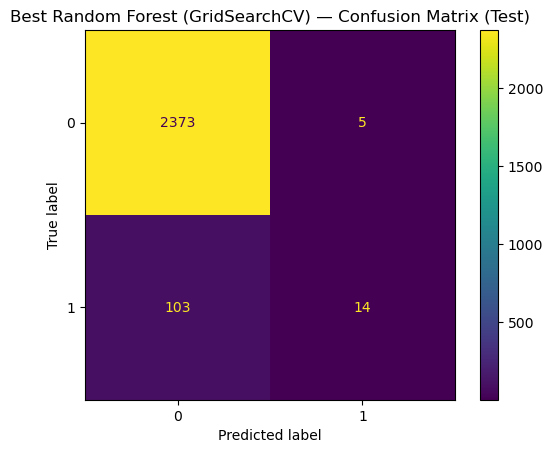

In [60]:
# visualize TP/FP/TN/FN counts for the tuned model on the test set
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    values_format="d",
)

# add a readable title and render the plot
plt.title("Best Random Forest (GridSearchCV) — Confusion Matrix (Test)")
plt.show()

In [61]:
# build a compact comparison table between the baseline and tuned random forest
compare3 = pd.DataFrame(
    [
        {"model": "LogReg baseline", **baseline_metrics},
        {"model": "RF (tuned)", **best_metrics},
    ]
).set_index("model")

# display the comparison table
compare3

,precision,recall,f1,roc_auc
model,,,,
LogReg baseline,0.000000,0.000000,0.000000,0.560871
RF (tuned),0.736842,0.119658,0.205882,0.845370


In [62]:
# extract the fitted random forest model from the tuned pipeline 
rf_model = best_rf.named_steps["randomforestclassifier"]

# build a Series of feature importances indexed by the feature column names
# sort descending so the most important features appear first
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols,
).sort_values(ascending=False)

# inspect the top 10 most important features
importances.head(10)

feat_27    0.054118
feat_24    0.050627
feat_26    0.035176
feat_13    0.034804
feat_16    0.032544
feat_46    0.030304
feat_34    0.025587
feat_38    0.025503
feat_5     0.022572
feat_6     0.022121
dtype: float64

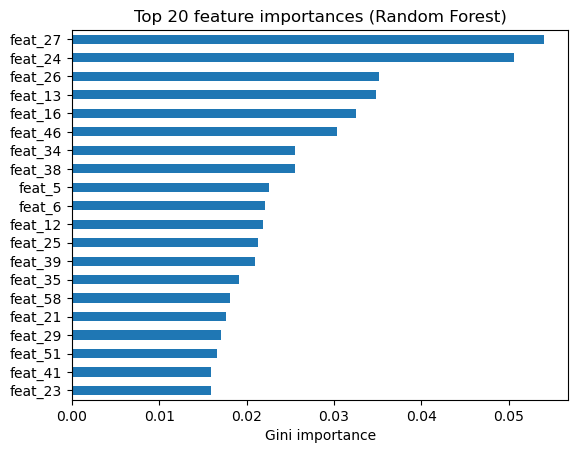

In [63]:
# choose the top 20 features to visualize
top_n = 20

# plot the top importances as a horizontal bar chart 
ax = importances.head(top_n).sort_values().plot(kind="barh")

# label the plot clearly
ax.set_title(f"Top {top_n} feature importances (Random Forest)")
ax.set_xlabel("Gini importance")
plt.show()

In [64]:
# checkpoint: there must be one importance value per feature column
assert importances.shape[0] == len(feature_cols), (
    "Importances should exist for every feature column."
)

# checkpoint: importances are normalized and should not exceed 1
assert importances.max() <= 1.0 + 1e-12, "Importances should be <= 1."

---
### Gradient Boosting Model

In [66]:
poland_path = Path("C:/Users/HomePC/Downloads/Bankruptcy Prediction in Poland and Taiwan/Bankruptcy data/poland-bankruptcy-data-2009.json.gz")
poland_df = wrangle(poland_path)


poland_df.shape

(9977, 66)

In [67]:
# 1) Select the financial feature columns.
feature_cols = [c for c in poland_df.columns if c.startswith("feat_")]

# 2) Build X as a DataFrame with just the features.
X = poland_df[feature_cols]

# 3) Build y as an integer Series (0/1).
y = poland_df["bankrupt"].astype(int)


print(X.shape, y.shape)

(9977, 64) (9977,)


In [68]:
# Split once and reuse these arrays for all models below.
X_train, X_test, y_train, y_test = train_test_split(
    X,             
    y,             
    test_size=0.25,  
    random_state=42, 
    stratify=y,      
)

# Compare bankruptcy rates to confirm stratification worked.
y_train.mean(), y_test.mean()

(np.float64(0.04677893611333868), np.float64(0.0468937875751503))

In [69]:
# Oversample the minority class in the training set only.

ros = RandomOverSampler(
    random_state=42  
)

# Fit the oversampler on the training data and return the resampled arrays.
X_train_over, y_train_over = ros.fit_resample(
    X_train,  
    y_train,  
)

# After resampling, the class counts should be balanced (same number of 0s and 1s).
y_train_over.value_counts()

bankrupt
0    7132
1    7132
Name: count, dtype: int64

In [70]:
def compute_metrics(
    y_true: pd.Series,
    y_pred: pd.Series,
    y_proba: pd.Series,
) -> dict[str, float]:
    """Compute core metrics for imbalanced binary classification.

    Parameters
    ----------
    y_true
        True labels (0/1).
    y_pred
        Predicted labels (0/1).
    y_proba
        Predicted probabilities for class 1.

    Returns
    -------
    dict[str, float]
        Precision, recall, F1, ROC–AUC.
    """
    # Precision: of the predicted bankruptcies, how many were correct?
    # zero_division=0 avoids errors when a model predicts zero positives.
    precision = precision_score(y_true, y_pred, zero_division=0)

    # Recall: of the true bankruptcies, how many did we detect?
    recall = recall_score(y_true, y_pred, zero_division=0)

    # F1: harmonic mean of precision and recall (useful under imbalance).
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # ROC–AUC: evaluates how well predicted probabilities rank positives above negatives.
    # This uses y_proba (probability of class 1), not hard class labels.
    roc_auc = roc_auc_score(y_true, y_proba)

    # Return a consistent dictionary so all models can be compared uniformly.
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    }

In [71]:
# Baseline Gradient Boosting (train on oversampled data).
gb_baseline = make_pipeline(
    SimpleImputer(strategy="median"),  # fill missing numeric values
    GradientBoostingClassifier(random_state=42),  # boosting model (baseline)
)

# Fit on the oversampled training set so the model sees enough bankrupt examples.
gb_baseline.fit(X_train_over, y_train_over)

# Predict hard class labels (0/1) on the untouched test set.
y_pred_gb0 = gb_baseline.predict(X_test)

# Predict probabilities for the positive class (bankrupt = 1).
y_proba_gb0 = gb_baseline.predict_proba(X_test)[:, 1]

# Compute the core metrics using the helper for consistent evaluation.
gb0_metrics = compute_metrics(y_test, y_pred_gb0, y_proba_gb0)
gb0_metrics

{'precision': 0.2602739726027397,
 'recall': 0.6495726495726496,
 'f1': 0.37163814180929094,
 'roc_auc': 0.8827086613041197}

In [73]:
# Random Forest reference model (bagging).
rf = make_pipeline(
    SimpleImputer(strategy="median"),  
    RandomForestClassifier(
        n_estimators=300,       
        random_state=42,        
        n_jobs=-1,              
        class_weight="balanced" 
    ),
)

# Fit on the original training set (no oversampling here).
rf.fit(X_train, y_train)

# Predict hard labels on the test set.
y_pred_rf = rf.predict(X_test)

# Predict probabilities for class 1 (bankrupt).
y_proba_rf = pd.Series(rf.predict_proba(X_test)[:, 1])

# Score with the same helper to enable fair comparisons.
rf_metrics = compute_metrics(y_test, y_pred_rf, y_proba_rf)
rf_metrics

{'precision': 0.6666666666666666,
 'recall': 0.06837606837606838,
 'f1': 0.12403100775193798,
 'roc_auc': 0.8412226032074644}

In [74]:
# Tuned Gradient Boosting using a small, readable grid.
gb_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    GradientBoostingClassifier(random_state=42)
   
)

# Grid over a few key hyperparameters:
param_grid = {
    "gradientboostingclassifier__n_estimators":([100, 200]),
    "gradientboostingclassifier__learning_rate":([0.05, 1]),
    "gradientboostingclassifier__max_depth":([2,3]),
    "gradientboostingclassifier__subsample":([1.0, 0.8]),
}

# Use ROC–AUC for selection because it evaluates probability ranking
grid = GridSearchCV(
    gb_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,     
    n_jobs=-1 
)

# Fit the search on the oversampled training data (same as baseline GB training).
grid.fit(X_train_over, y_train_over)

# Inspect the best hyperparameters and best cross-validated ROC–AUC.
grid.best_params_, grid.best_score_

({'gradientboostingclassifier__learning_rate': 1,
  'gradientboostingclassifier__max_depth': 3,
  'gradientboostingclassifier__n_estimators': 200,
  'gradientboostingclassifier__subsample': 1.0},
 np.float64(0.9992928764102588))

In [75]:
# Evaluate the best tuned model on the test set.
gb_best = grid.best_estimator_

# Predict test labels and probabilities using the tuned pipeline.
y_pred_gb = gb_best.predict(X_test)
y_proba_gb = pd.Series(gb_best.predict_proba(X_test)[:, 1])

# Compute test metrics for the tuned model.
gb_metrics = compute_metrics(y_test, y_pred_gb, y_proba_gb)
gb_metrics

{'precision': 0.6428571428571429,
 'recall': 0.46153846153846156,
 'f1': 0.5373134328358209,
 'roc_auc': 0.8860656444760733}

In [76]:
# Combine metrics into a single comparison table.
# Each list item becomes one row in the final DataFrame.
# We store a readable model name under "model" and then unpack the metric dict.
comparison = pd.DataFrame(
    [
        {"model": "Random Forest", **rf_metrics},         # bagging reference
        {"model": "GradBoost (baseline)", **gb0_metrics},  # boosting baseline
        {"model": "GradBoost (tuned)", **gb_metrics},      # tuned boosting model
    ]
)

# Use the model name as the row index so the table reads naturally.
comparison = comparison.set_index("model")

# Display the comparison table (rows = models, columns = metrics).
comparison

,precision,recall,f1,roc_auc
model,,,,
Random Forest,0.666667,0.068376,0.124031,0.841223
GradBoost (baseline),0.260274,0.649573,0.371638,0.882709
GradBoost (tuned),0.642857,0.461538,0.537313,0.886066


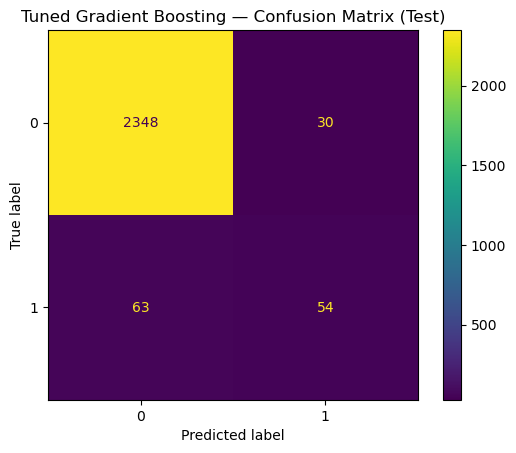

              precision    recall  f1-score   support

           0      0.974     0.987     0.981      2378
           1      0.643     0.462     0.537       117

    accuracy                          0.963      2495
   macro avg      0.808     0.724     0.759      2495
weighted avg      0.958     0.963     0.960      2495



In [78]:
# Confusion matrix + report for the tuned Gradient Boosting model.
ConfusionMatrixDisplay.from_predictions(
    y_test,        
    y_pred_gb,     
    values_format="d",  
)

# Add a descriptive title so the plot is self-explanatory in the notebook.
plt.title("Tuned Gradient Boosting — Confusion Matrix (Test)")
plt.show()

# The classification report gives precision/recall/F1 for each class (0 and 1).
print(classification_report(y_test, y_pred_gb, digits=3, zero_division=0))

In [79]:
# Optional: explore thresholds to see the precision/recall trade-off.
def threshold_demo(threshold: float = 0.5) -> None:
    """Display metrics and a confusion matrix for a chosen threshold."""
    y_pred_thr = (y_proba_gb >= threshold).astype(int)

    # Compute the confusion matrix counts for this threshold.
    cm = confusion_matrix(
        y_test,     # true labels
        y_pred_thr, # thresholded predictions
    )

    # Print key metrics so you can see how the threshold shifts the trade-off.
    print(
        "precision:",
        precision_score(y_test, y_pred_thr, zero_division=0),
        "recall:",
        recall_score(y_test, y_pred_thr, zero_division=0),
        "f1:",
        f1_score(y_test, y_pred_thr, zero_division=0),
    )

    # Plot the confusion matrix for the chosen threshold.
    ConfusionMatrixDisplay(cm).plot(values_format="d")
    plt.title(f"Threshold = {threshold:.2f}")
    plt.show()

In [80]:
# Try a few thresholds and observe how the confusion matrix changes.
# Use a slider to interactively choose the cutoff and rerun threshold_demo.
interact(
    threshold_demo,
    threshold=widgets.FloatSlider(
        value=0.5,  
        min=0.05,   
        max=0.95,   
        step=0.05,  
    ),
);

interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.95, min=0.05, step=0.05), Output()…

In [81]:
# Create a folder to store trained models.
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

# Save the tuned Gradient Boosting model to .
model_path = model_dir / "poland_gradient_boosting.pkl"

with model_path.open("wb") as f:
    pickle.dump(grid.best_estimator_, f)

model_path

WindowsPath('models/poland_gradient_boosting.pkl')

In [82]:
# Load the model back from disk.
with model_path.open("rb") as f:
    loaded_model = pickle.load(f)

In [83]:
# Predict again on X_test to confirm the loaded model works.
loaded_proba = loaded_model.predict_proba(X_test)[:, 1]
loaded_pred = (loaded_proba >= 0.5).astype(int)

loaded_metrics = compute_metrics(
    y_test,
    pd.Series(loaded_pred),
    pd.Series(loaded_proba),
)
loaded_metrics

{'precision': 0.6428571428571429,
 'recall': 0.46153846153846156,
 'f1': 0.5373134328358209,
 'roc_auc': 0.8860656444760733}

In [84]:
predictor_code = '''
from __future__ import annotations

import pickle
from pathlib import Path

import pandas as pd

from data import wrangle

def predict_bankruptcy_prob(
    model_path: str | Path,
    data_path: str | Path,
) -> pd.Series:
    """Predict bankruptcy probabilities for a dataset file.

    Parameters
    ----------
    model_path
        Path to a trained scikit-learn pipeline saved with pickle.
    data_path
        Path to a dataset file compatible with ``wrangle``.

    Returns
    -------
    pd.Series
        Predicted probabilities for class 1 (bankrupt), indexed by row id.
    """
    model_path = Path(model_path)
    data_path = Path(data_path)

    with model_path.open("rb") as f:
        model = pickle.load(f)

    df = wrangle(data_path)
    feat_cols = [c for c in df.columns if c.startswith("feat_")]
    X = df[feat_cols]

    proba = model.predict_proba(X)[:, 1]
    return pd.Series(proba, index=df.index)

if __name__ == "__main__":
    model_path = Path("models/poland_gradient_boosting.pkl")
    data_path = Path("data/poland-bankruptcy-data-2009.json.gz")

    probs = predict_bankruptcy_prob(model_path, data_path)
    print(probs.head())
'''

Path("predictor.py").write_text(predictor_code, encoding="utf-8")
Path("predictor.py")

WindowsPath('predictor.py')